#Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Setting plot style for better visuals
plt.style.use('fivethirtyeight')
%matplotlib inline

#Load Food Data and Inject Fuel Prices

In [25]:
# 1. Load your dataset
df = pd.read_csv('clean_food_price.csv')

# 2. Clean up column names (removes spaces and makes them lowercase)
df.columns = df.columns.str.strip().str.lower()
print("Your columns are:", df.columns.tolist())

# 3. Handle the Date column
# If your date column is named something else (like 'month'), change 'date' below
date_col = 'date' 
df[date_col] = pd.to_datetime(df[date_col])
df.set_index(date_col, inplace=True)
df = df.sort_index()

# 4. INJECT FUEL DATA
# We map the year to the official Uganda fuel prices
fuel_prices = {
    2017: 3549, 
    2018: 4023, 
    2019: 4085, 
    2020: 3851, 
    2021: 4051
}

df['fuel_price'] = df.index.year.map(fuel_prices)

print("\n--- Data Ready ---")
print(df[['commodity', 'price', 'fuel_price']].head())

Your columns are: ['commodity', 'date', 'price']

--- Data Ready ---
                commodity        price  fuel_price
date                                              
2017-01-01          beans  2683.250000        3549
2017-01-01  maize (white)  1350.000000        3549
2017-01-01        sorghum  1704.166667        3549
2017-02-01          beans  2773.666667        3549
2017-02-01  maize (white)  1291.666667        3549


#Training with numeric_only=True

In [43]:
from sklearn.preprocessing import StandardScaler
from pmdarima import auto_arima

# Scale data
scaler = StandardScaler()
item_df[['price','fuel_price']] = scaler.fit_transform(item_df[['price','fuel_price']])

# Auto ARIMA to find best parameters
auto_model = auto_arima(
    item_df['price'],
    exogenous=item_df[['fuel_price']],
    seasonal=True,
    m=12,
    suppress_warnings=True
)

#Training the SARIMAX Models

In [46]:
from pmdarima import auto_arima
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd

results = {}

# 🔹 Ensure date is correct ONCE (important fix)
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')
df = df.sort_index()

# 🔹 Commodities list
commodities = ['beans', 'sorghum', 'maize (white)']

for item in commodities:
    print(f"\n--- Processing {item.upper()} ---")

    # 🔹 1. Filter data
    item_df = df[df['commodity'].str.strip().str.lower() == item].copy()

    if item_df.empty:
        print(f"Skipping {item}: no data after filtering")
        continue

    # 🔹 2. Convert numeric
    item_df['price'] = pd.to_numeric(item_df['price'], errors='coerce')
    item_df['fuel_price'] = pd.to_numeric(item_df['fuel_price'], errors='coerce')

    # 🔹 3. Resample time series
    item_df = item_df.resample('MS').mean(numeric_only=True)

    # 🔹 4. Fix missing values (IMPORTANT)
    item_df['price'] = item_df['price'].interpolate()
    item_df['fuel_price'] = item_df['fuel_price'].ffill()

    item_df = item_df.dropna(subset=['price'])

    if item_df.empty:
        print(f"Skipping {item}: empty after cleaning")
        continue

    # 🔹 5. Scale data (NO warnings version)
    scaler = StandardScaler()
    scaled_values = scaler.fit_transform(item_df[['price', 'fuel_price']].values)
    item_df[['price', 'fuel_price']] = scaled_values

    # 🔹 6. Auto ARIMA tuning
    auto_model = auto_arima(
        item_df['price'],
        exogenous=item_df[['fuel_price']],
        seasonal=True,
        m=12,
        suppress_warnings=True,
        stepwise=True
    )

    print(f"Best order for {item}: {auto_model.order}")
    print(f"Best seasonal order: {auto_model.seasonal_order}")

    # 🔹 7. Train SARIMAX
    model = SARIMAX(
        item_df['price'],
        exog=item_df[['fuel_price']],
        order=auto_model.order,
        seasonal_order=auto_model.seasonal_order,
        enforce_stationarity=True,
        enforce_invertibility=True
    )

    model_fit = model.fit(method='lbfgs', maxiter=500, disp=False)

    # 🔹 8. Future fuel (2022 forecast)
    future_fuel = np.array([4051] * 6)

    future_df = pd.DataFrame({
        'price': np.zeros(6),
        'fuel_price': future_fuel
    })

    future_scaled = scaler.transform(future_df.values)
    future_exog = future_scaled[:, 1].reshape(-1, 1)

    # 🔹 9. Forecast
    forecast = model_fit.get_forecast(steps=6, exog=future_exog)

    forecast_scaled = forecast.predicted_mean

    # 🔹 10. Convert back to real values
    combined = np.column_stack([forecast_scaled, future_exog.flatten()])
    forecast_real = scaler.inverse_transform(combined)[:, 0]

    print(f"\n📊 Forecast for {item}:")
    print(np.round(forecast_real, 2))

    # 🔹 Save results
    results[item] = forecast_real


--- Processing BEANS ---
Best order for beans: (1, 0, 0)
Best seasonal order: (1, 0, 0, 12)

📊 Forecast for beans:
[2373.38 2334.15 2548.4  2548.75 2655.77 2570.51]

--- Processing SORGHUM ---
Best order for sorghum: (0, 1, 1)
Best seasonal order: (0, 0, 0, 12)

📊 Forecast for sorghum:
[1289.01 1289.01 1289.01 1289.01 1289.01 1289.01]

--- Processing MAIZE (WHITE) ---
Best order for maize (white): (1, 0, 1)
Best seasonal order: (0, 0, 0, 12)

📊 Forecast for maize (white):
[1049.49 1067.19 1078.76 1086.33 1091.27 1094.5 ]


In [61]:
for item in commodities:
    item_df = df[df['commodity'].str.strip().str.lower() == item].copy()

    item_df['price'] = pd.to_numeric(item_df['price'], errors='coerce')
    item_df['fuel_price'] = pd.to_numeric(item_df['fuel_price'], errors='coerce')

    item_df = item_df.resample('MS').mean(numeric_only=True)

    item_df['price'] = item_df['price'].interpolate()
    item_df['fuel_price'] = item_df['fuel_price'].ffill()

    item_df = item_df.dropna(subset=['price'])

    print(item, "shape:", item_df.shape)

beans shape: (60, 2)
sorghum shape: (60, 2)
maize (white) shape: (60, 2)


#Visualization and Accuracy Check

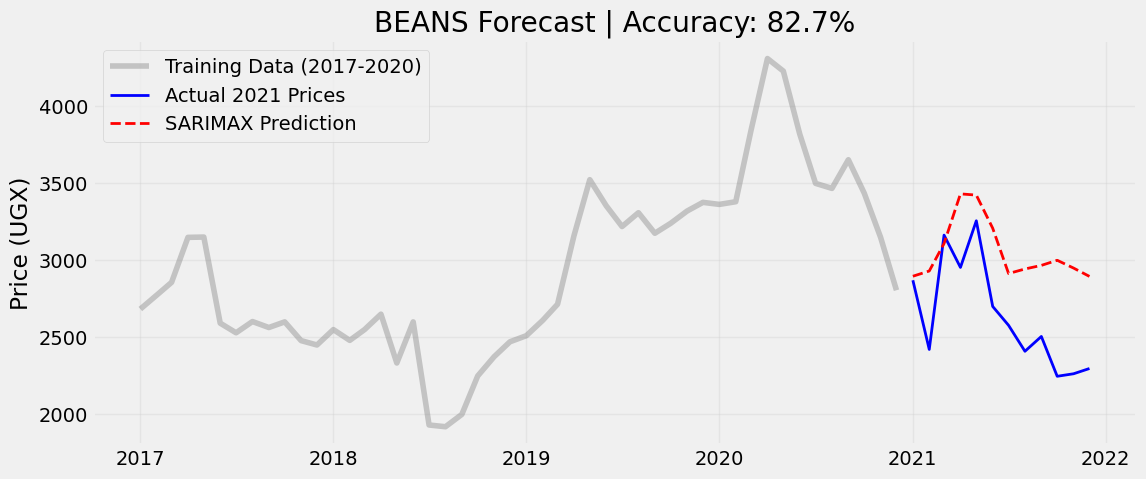

Results for beans: RMSE = 481.08 UGX | MAPE = 17.25%


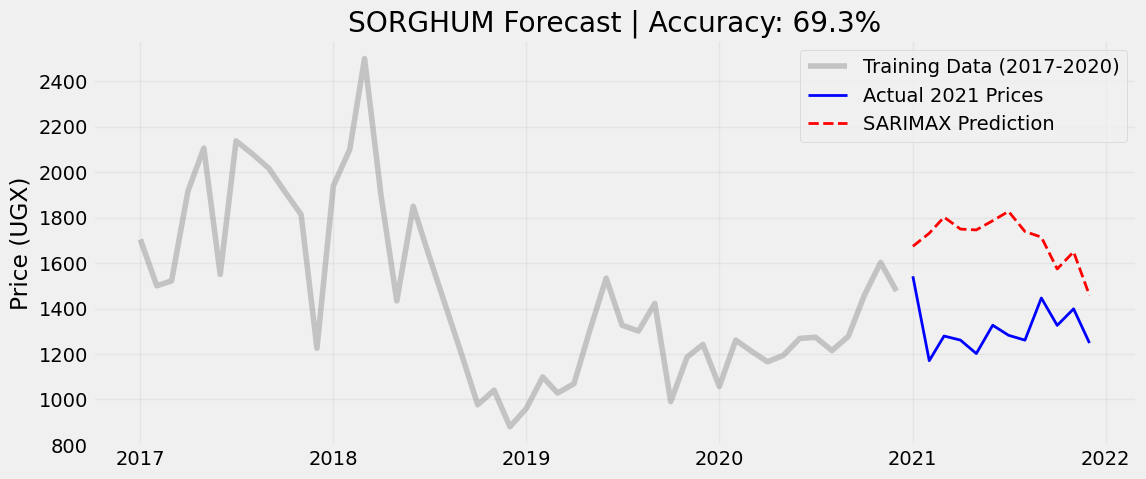

Results for sorghum: RMSE = 420.12 UGX | MAPE = 30.71%


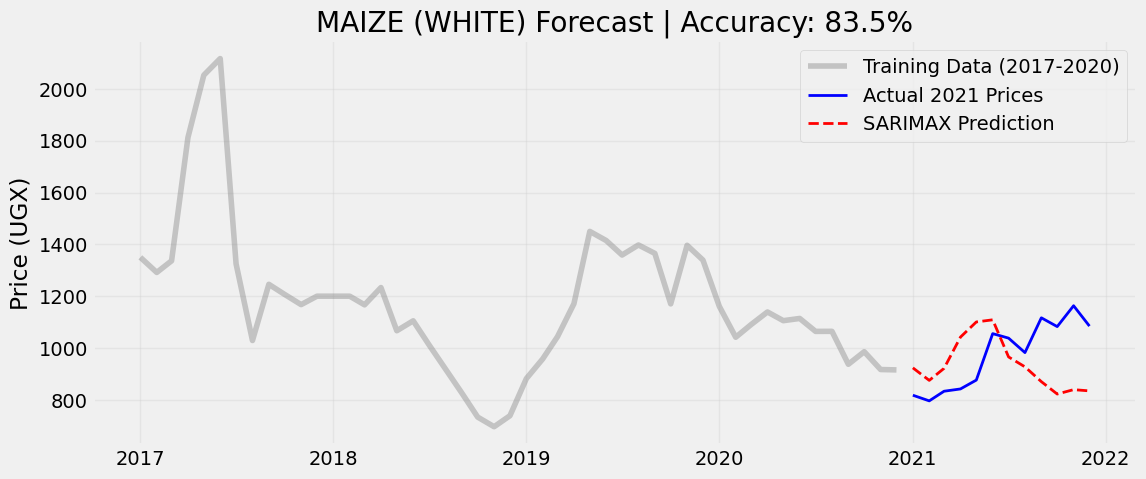

Results for maize (white): RMSE = 187.62 UGX | MAPE = 16.45%


In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

for item in results_dict.keys():
    actual = results_dict[item]['actual']
    pred = results_dict[item]['pred']
    train = results_dict[item]['train']
    
    # Calculate Accuracy
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = mean_absolute_percentage_error(actual, pred)
    accuracy = (1 - mape) * 100
    
    # Plotting
    plt.figure(figsize=(12, 5))
    plt.plot(train, label='Training Data (2017-2020)', color='gray', alpha=0.4)
    plt.plot(actual, label='Actual 2021 Prices', color='blue', linewidth=2)
    plt.plot(pred, label='SARIMAX Prediction', color='red', linestyle='--', linewidth=2)
    
    plt.title(f"{item.upper()} Forecast | Accuracy: {accuracy:.1f}%")
    plt.ylabel('Price (UGX)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Results for {item}: RMSE = {rmse:.2f} UGX | MAPE = {mape:.2%}")

#Future Predictions for 2022

In [56]:
for item in commodities:
    item_df = df[df['commodity'].str.strip().str.lower() == item].copy()

    item_df['price'] = pd.to_numeric(item_df['price'], errors='coerce')
    item_df['fuel_price'] = pd.to_numeric(item_df['fuel_price'], errors='coerce')

    # ✅ FIXED LINE (NO COMMA)
    item_df = item_df.resample('MS').mean(numeric_only=True)

    # ✅ Fix missing data instead of deleting everything
    item_df['price'] = item_df['price'].interpolate()
    item_df['fuel_price'] = item_df['fuel_price'].ffill()

    item_df = item_df.dropna(subset=['price'])

    print(f"{item} after fix:", item_df.shape)

    if item_df.empty:
        print(f"Skipping {item}: No valid data.")
        continue

    final_model = SARIMAX(
    item_df['price'],
    exog=item_df[['fuel_price']],
    order=(1,1,0),              # 🔥 simpler AR structure
    seasonal_order=(0,0,0,0),   # 🔥 removes seasonal instability completely
    enforce_stationarity=True,
    enforce_invertibility=True,
    initialization='approximate_diffuse'  # 🔥 key fix
    )

    final_fit = final_model.fit(disp=False)

    future_fuel = np.array([4051]*6).reshape(-1,1)

    forecast = final_fit.get_forecast(steps=6, exog=future_fuel)

    print(f"\nForecast for {item}:")
    print(forecast.predicted_mean)

beans after fix: (60, 2)

Forecast for beans:
2022-01-01    2296.691613
2022-02-01    2296.714761
2022-03-01    2296.714157
2022-04-01    2296.714173
2022-05-01    2296.714172
2022-06-01    2296.714172
Freq: MS, Name: predicted_mean, dtype: float64
sorghum after fix: (60, 2)

Forecast for sorghum:
2022-01-01    1278.075285
2022-02-01    1272.118715
2022-03-01    1273.303699
2022-04-01    1273.067961
2022-05-01    1273.114858
2022-06-01    1273.105529
Freq: MS, Name: predicted_mean, dtype: float64
maize (white) after fix: (60, 2)

Forecast for maize (white):
2022-01-01    1074.063649
2022-02-01    1072.637941
2022-03-01    1072.445881
2022-04-01    1072.420009
2022-05-01    1072.416523
2022-06-01    1072.416054
Freq: MS, Name: predicted_mean, dtype: float64
